# LM Extraction
**Model:** Llama 3.1 8B via Ollama (local, no API key required)  
**Input:** BigQuery Gold tables — `gold_pre_launch`, `gold_post_launch`  
**Output:** `data/extracted/thesis_extracted.csv` — long-format, one row per product × feature  

Run cells in order. The extraction loops (Cells 5 & 6) are **checkpoint-safe** — interrupt and restart at any time without reprocessing completed documents.  

**Before running:** ensure Ollama is serving the model in a separate terminal:
```
ollama serve
ollama pull llama3.1
```

In [1]:
# ============================================================
# CELL 1 — Imports & Config
# ============================================================
import re
import json
import time
import logging
import random
from pathlib import Path

import pandas as pd
import numpy as np
import ollama
from google.cloud import bigquery

# ── Config ────────────────────────────────────────────────
PROJECT_ID  = "vuthesis-llm-buzz"
DATASET_ID  = "thesis_dataset"
EVENTS_CSV  = Path("final_events.csv")
OUTPUT_DIR  = Path("data/extracted")
CACHE_DIR   = Path("data/cache")
LOG_DIR     = Path("logs")
MODEL       = "llama3.1"
RANDOM_SEED = 42

REFRESH_CACHE = False

# ── Unified feature set (hedonic + utilitarian) ───────────
# Same four features across all products — required for OLS
FEATURES = ["battery", "price", "performance", "display"]

# Keyword pre-filter: a post must contain at least one of these
# keywords to trigger the two-step Syn-Chain call for that feature.
# Avoids wasted LLM calls on posts that clearly don't mention a feature.
FEATURE_KEYWORDS = {
    "battery":     ["battery", "batt", "charge", "charging", "mah", "life"],
    "price":       ["price", "cost", "expensive", "cheap", "afford", "dollar",
                    "£", "€", "$", "worth", "value", "msrp"],
    "performance": ["performance", "speed", "fast", "slow", "lag", "chip",
                    "processor", "cpu", "benchmark", "ram", "smooth", "snapdragon",
                    "a1", "m1", "m2", "m3", "m4", "exynos", "mediatek"],
    "display":     ["display", "screen", "resolution", "hz", "oled", "amoled",
                    "lcd", "brightness", "nit", "refresh", "panel"],
}

# Sentiment & intensity → numeric mappings (used in aggregation)
SENTIMENT_MAP = {"positive": 1.0, "negative": -1.0, "neutral": 0.0, "mixed": 0.0}
INTENSITY_MAP = {"high": 3, "medium": 2, "low": 1}

TEXT_CHAR_LIMIT = 1200

for d in [OUTPUT_DIR, CACHE_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Logging ───────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    handlers=[
        logging.FileHandler(LOG_DIR / "stage5_extraction.log"),
        logging.StreamHandler(),
    ],
)
log = logging.getLogger(__name__)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

log.info("Stage 5 initialised — model: %s | features: %s", MODEL, FEATURES)


2026-05-26 20:17:41,935  INFO  Stage 5 initialised — model: llama3.1 | features: ['battery', 'price', 'performance', 'display']


In [43]:
# ============================================================
# CELL 2 — Load Events Reference Table
# ============================================================
events = pd.read_csv(EVENTS_CSV)
events = events.dropna(subset=["product_name"]).reset_index(drop=True)

# Snake_case event keys matching the Gold table product_event column
THESIS_EVENTS = {
    "ipad_pro_2018", "ipad_air_m1", "galaxy_s6", "galaxy_s20_fe",
    "galaxy_s22_ultra", "lg_g3", "moto_g_fast", "pixel_3a",
    "pixel_4a", "galaxy_tab_s2"
}

# Map display names to snake_case keys
NAME_TO_EVENT = {
    "iPad Pro 2018":          "ipad_pro_2018",
    "iPad Air M1":            "ipad_air_m1",
    "Samsung Galaxy S6":      "galaxy_s6",
    "Samsung Galaxy S20 FE":  "galaxy_s20_fe",
    "Samsung Galaxy S22 Ultra": "galaxy_s22_ultra",
    "LG G3":                  "lg_g3",
    "Moto G Fast":            "moto_g_fast",
    "Google Pixel 3a":        "pixel_3a",
    "Google Pixel 4a":        "pixel_4a",
    "Galaxy Tab S2":          "galaxy_tab_s2",
    "Moto G3":                    "moto_g_3rd_gen",
    "iPad Air 2":                 "ipad_air_2",
    "Samsung Galaxy S21 Ultra":   "galaxy_s21_ultra",
}
events["product_event"] = events["product_name"].map(NAME_TO_EVENT)

# Normalise product_type to lowercase for consistent key lookups
# Support both integer (1/0) and string ("hedonic"/"utilitarian") encodings
events["product_type"] = events["product_type"].astype(str).str.strip().str.lower()
events["product_type"] = events["product_type"].replace({
    "1": "hedonic", "0": "utilitarian",
    "1.0": "hedonic", "0.0": "utilitarian"
})

print(f"Events loaded: {len(events)} products")
print(events[["product_name", "brand", "launch_date", "product_type"]].to_string(index=False))


Events loaded: 13 products
            product_name    brand launch_date product_type
           iPad Pro 2018    Apple  07/11/2018      hedonic
             iPad Air M1    Apple  18/03/2022      hedonic
       Samsung Galaxy S6  Samsung  10/04/2015      hedonic
   Samsung Galaxy S20 FE  Samsung  02/10/2020      hedonic
Samsung Galaxy S22 Ultra  Samsung  25/02/2022      hedonic
                   LG G3       LG  18/07/2014      hedonic
             Moto G Fast Motorola  18/06/2020  utilitarian
         Google Pixel 3a   Google  07/05/2019  utilitarian
         Google Pixel 4a   Google  20/08/2020  utilitarian
           Galaxy Tab S2  Samsung  21/08/2015  utilitarian
                 Moto G3 Motorola  28/07/2015  utilitarian
              iPad Air 2    Apple  22/10/2014      hedonic
Samsung Galaxy S21 Ultra  Samsung  29/01/2021      hedonic


In [44]:
# ============================================================
# CELL 3 — Load Gold Tables from BigQuery (with Parquet cache)
# ============================================================
import pyarrow.parquet as pq

bq = bigquery.Client(project=PROJECT_ID)

def load_gold_table(table_name: str) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{table_name}.parquet"
    if not REFRESH_CACHE and cache_path.exists():
        log.info("Loading %-25s from cache", table_name)
        # Read via PyArrow directly to bypass dbdate metadata errors
        # from BigQuery-generated Parquet files
        table = pq.read_table(str(cache_path))
        return table.to_pandas(timestamp_as_object=True, date_as_object=True)
    log.info("Pulling %-25s from BigQuery ...", table_name)
    df = bq.query(
        f"SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`"
    ).to_dataframe()
    # Cast date columns to string before saving to avoid dbdate reload errors
    df_save = df.copy()
    for col in df_save.columns:
        if hasattr(df_save[col], "dtype") and "date" in str(df_save[col].dtype).lower():
            df_save[col] = df_save[col].astype(str)
    df_save.to_parquet(cache_path, index=False)
    log.info("Cached  %-25s  (%d rows)", table_name, len(df))
    return df

df_pre  = load_gold_table("gold_pre_launch")
df_post = load_gold_table("gold_post_launch")

log.info("Pre-launch rows : %d", len(df_pre))
log.info("Post-launch rows: %d", len(df_post))

assert "post_id"       in df_pre.columns,  "gold_pre_launch missing 'post_id'"
assert "text"          in df_pre.columns,  "gold_pre_launch missing 'text'"
assert "product_event" in df_pre.columns,  "gold_pre_launch missing 'product_event'"
assert "review_id"     in df_post.columns, "gold_post_launch missing 'review_id'"
assert "text"          in df_post.columns, "gold_post_launch missing 'text'"
assert "product_event" in df_post.columns, "gold_post_launch missing 'product_event'"

print("\nPre-launch sample:")
print(df_pre[["post_id", "product_event", "text"]].head(2).to_string(index=False))
print("\nPost-launch sample:")
print(df_post[["review_id", "product_event", "text"]].head(2).to_string(index=False))


2026-06-01 21:29:02,374  INFO  Loading gold_pre_launch           from cache
2026-06-01 21:29:03,360  INFO  Loading gold_post_launch          from cache
2026-06-01 21:29:03,681  INFO  Pre-launch rows : 36459
2026-06-01 21:29:03,683  INFO  Post-launch rows: 4329



Pre-launch sample:
        post_id product_event                                               text
comment_gbg3gah galaxy_s20_fe  ||| So much for the S21 series not being flagship
comment_gbglk0n galaxy_s20_fe                              ||| 2K+, as in 1080p?

Post-launch sample:
       review_id product_event                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [18]:
# ============================================================
# CELL 4 — Syn-Chain Prompt Templates & Extraction Functions
#
# Implements the simplified 2-step Syn-Chain approach from
# Fan et al. (2025), adapted for sub-10B models.
#
# Full Syn-Chain (CoNLL-U syntactic parsing) is omitted because
# Fan et al. show it degrades performance on models ≤ 8B zero-shot.
# The simplified version retains the decomposed reasoning chain
# (opinion extraction → sentiment classification) which drives
# the performance gains, without the syntactic parsing overhead.
#
# Pipeline per document
# ─────────────────────
# A. Overall sentiment + competitor mentions → single pass (no
#    decomposition needed; not aspect-level tasks)
#
# B. Per feature (battery / price / performance / display):
#    1. Keyword pre-filter — skip if feature clearly not mentioned
#    2. Step 1 (Opinion Extraction) → R1
#       "What words/phrases does the author use to describe {feature}?"
#    3. If R1 = "not mentioned" → skip Step 2
#    4. Step 2 (Sentiment Classification) → R2
#       Uses original text + R1 as chained context
#    5. Parse R2 into {sentiment, intensity, reasoning}
#    6. Convert to numeric score: sentiment × intensity weight
# ============================================================

# ── A. Overall sentiment & competitor mentions ────────────

SYS_OVERALL = (
    "You are a sentiment analysis assistant. Extract structured information "
    "from consumer text. Respond with valid JSON only — no explanation, "
    "no preamble, no markdown fences."
)

def build_overall_prompt(text: str, product_name: str) -> str:
    text_clipped = text[:TEXT_CHAR_LIMIT].replace('"', "'")
    return (
        f"Analyse this consumer text about the {product_name}.\n\n"
        f"Text:\n---\n{text_clipped}\n---\n\n"
        "Extract the following and return JSON only.\n\n"
        "1. overall_sentiment\n"
        "   Float from -1.0 (very negative) to 1.0 (very positive) reflecting\n"
        f"   the author's overall attitude toward the {product_name}.\n\n"
        "2. brand_mentions\n"
        "   List ALL smartphone, tablet, or device brand names or product names\n"
        "   mentioned anywhere in the text — regardless of context.\n"
        "   Include brand names, product line names, and specific model names.\n"
        "   Do NOT include: accessory brands (OtterBox, Spigen), retailers\n"
        "   (Amazon, BestBuy), services (Spotify, Google Maps), or chipset\n"
        "   names unless they clearly refer to a device (e.g. Snapdragon is a\n"
        "   chip, not a device — exclude it).\n"
        "   Return [] if no device brand or product names are mentioned.\n\n"
        "Required JSON format:\n"
        "{\n"
        '  "overall_sentiment": <float -1.0 to 1.0>,\n'
        '  "brand_mentions": ["<brand_name_1>", "<brand_name_2>"]\n'
        "}"
    )


def extract_overall(text: str, product_name: str,
                    max_retries: int = 3) -> dict | None:
    """
    Single-pass extraction of overall sentiment (IV1/DV aggregate)
    and competitor co-mentions (IV3).
    Returns parsed dict or None on failure.
    """
    prompt = build_overall_prompt(text, product_name)

    for attempt in range(max_retries):
        try:
            resp = ollama.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYS_OVERALL},
                    {"role": "user",   "content": prompt},
                ],
                options={
                    "temperature": 0.0,
                    "num_predict": 200,   # JSON never exceeds ~100 tokens
                    "num_ctx":     1024,
                },
                format="json",
            )
            raw = resp["message"]["content"].strip()
            if raw.startswith("```"):
                raw = raw.split("```")[1]
                if raw.startswith("json"):
                    raw = raw[4:]
            result = json.loads(raw.strip())

            assert "overall_sentiment" in result
            assert "brand_mentions"      in result
            assert isinstance(result["brand_mentions"], list)

            # Replace nulls with safe defaults before clipping
            if result["overall_sentiment"] is None:
                result["overall_sentiment"] = 0.0
            result["overall_sentiment"] = float(
                np.clip(result["overall_sentiment"], -1, 1)
            )
            # Normalise brand_mentions to list of lowercase strings
            result["brand_mentions"] = [
                str(b).lower().strip()
                for b in result["brand_mentions"]
                if b
            ]
            return result

        except Exception as e:
            wait = 2 ** attempt
            log.warning("Overall extraction attempt %d/%d failed: %s — retry in %ds",
                        attempt + 1, max_retries, e, wait)
            time.sleep(wait)

    log.error("Overall extraction failed for [%s] after %d retries.", product_name, max_retries)
    return None


# ── B. Syn-Chain: Step 1 — Opinion Extraction ────────────

SYS_STEP1 = (
    "You are an assistant analyzing consumer opinions about upcoming products. "
    "I will give you a social media post and a specific product feature. "
    "Identify any words or phrases the author uses to describe or evaluate that feature. "
    "Keep your response under 120 words. Be precise and quote directly from the post."
)

def build_step1_prompt(text: str, feature: str) -> str:
    text_clipped = text[:TEXT_CHAR_LIMIT].replace('"', "'")
    return (
        f'Post: "{text_clipped}"\n\n'
        f'Feature: "{feature}"\n\n'
        f'What words or phrases does the author use to describe or evaluate "{feature}"?\n'
        'If the feature is not meaningfully discussed, say "not mentioned".'
    )


# ── B. Syn-Chain: Step 2 — Sentiment Classification ──────

SYS_STEP2 = (
    "You are a sentiment analysis expert specializing in pre-launch consumer expectations. "
    "I will provide a social media post, a product feature, and an opinion description. "
    "Classify the sentiment and intensity toward that feature.\n\n"
    "Output format — use exactly this structure:\n"
    "Sentiment: {positive / negative / neutral / mixed}\n"
    "Intensity: {low / medium / high}\n"
    "Because: ..."
)

def build_step2_prompt(text: str, feature: str, r1: str) -> str:
    text_clipped = text[:TEXT_CHAR_LIMIT].replace('"', "'")
    return (
        f'Post: "{text_clipped}"\n\n'
        f'Feature: "{feature}"\n\n'
        f'Opinion description: "{r1}"\n\n'
        f'Based on this opinion, what is the author\'s anticipatory sentiment '
        f'toward "{feature}" in the upcoming product?'
    )


# ── B. Syn-Chain: parsing R2 output ──────────────────────

def parse_r2(r2_text: str) -> dict | None:
    """
    Parse the structured text output of Step 2 into a dict.
    Returns None if required fields are missing.
    """
    sentiment_match = re.search(
        r"Sentiment:\s*(positive|negative|neutral|mixed)",
        r2_text, re.IGNORECASE
    )
    intensity_match = re.search(
        r"Intensity:\s*(low|medium|high)",
        r2_text, re.IGNORECASE
    )
    reasoning_match = re.search(
        r"Because:\s*(.+)", r2_text, re.IGNORECASE | re.DOTALL
    )

    if not sentiment_match or not intensity_match:
        return None

    sentiment_label = sentiment_match.group(1).lower()
    intensity_label = intensity_match.group(1).lower()

    # Convert to numeric score: sentiment polarity × intensity weight
    # Intensity weights: high=1.0, medium=0.67, low=0.33
    # This preserves both direction and strength in a single float [-1, 1]
    intensity_weight = {3: 1.0, 2: 0.67, 1: 0.33}[INTENSITY_MAP[intensity_label]]
    numeric_score = float(SENTIMENT_MAP[sentiment_label] * intensity_weight)

    return {
        "sentiment_label": sentiment_label,
        "intensity_label": intensity_label,
        "sentiment_score": round(numeric_score, 4),
        "reasoning": reasoning_match.group(1).strip() if reasoning_match else "",
    }


# ── B. Syn-Chain: full two-step call per feature ─────────

def extract_feature_synchain(text: str, product_name: str, feature: str,
                              max_retries: int = 3) -> dict | None:
    """
    Two-step Syn-Chain extraction for one feature in one document.

    Step 1: Opinion extraction → R1
    Step 2: Sentiment classification using text + R1 → R2
    Returns parsed dict with sentiment_label, intensity_label,
    sentiment_score, and reasoning. Returns None if feature is
    not mentioned or if all retries fail.
    """
    # ── Keyword pre-filter ────────────────────────────────
    # Skip the two LLM calls entirely if none of the feature's
    # keywords appear in the lowercased text. This avoids wasting
    # calls on posts that clearly don't discuss this feature.
    text_lower = text.lower()
    keywords   = FEATURE_KEYWORDS.get(feature, [feature])
    if not any(kw in text_lower for kw in keywords):
        return None   # Not mentioned — skip silently

    # ── Step 1 — Opinion extraction ───────────────────────
    r1 = None
    for attempt in range(max_retries):
        try:
            resp = ollama.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYS_STEP1},
                    {"role": "user",   "content": build_step1_prompt(text, feature)},
                ],
                options={
                    "temperature": 0.0,
                    "num_predict": 150,   # Step 1 output capped at 120 words per prompt
                    "num_ctx":     1024,
                },
            )
            r1 = resp["message"]["content"].strip()
            break
        except Exception as e:
            wait = 2 ** attempt
            log.warning("Step 1 attempt %d/%d [%s / %s]: %s — retry in %ds",
                        attempt + 1, max_retries, product_name, feature, e, wait)
            time.sleep(wait)

    if r1 is None:
        log.error("Step 1 failed for [%s / %s].", product_name, feature)
        return None

    # If the model says the feature is not discussed, stop here
    if "not mentioned" in r1.lower():
        return None

    # ── Step 2 — Sentiment classification (chained) ───────
    r2 = None
    for attempt in range(max_retries):
        try:
            resp = ollama.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYS_STEP2},
                    {"role": "user",   "content": build_step2_prompt(text, feature, r1)},
                ],
                options={
                    "temperature": 0.0,
                    "num_predict": 100,   # Sentiment/Intensity/Because fits in ~80 tokens
                    "num_ctx":     1024,
                },
            )
            r2 = resp["message"]["content"].strip()
            break
        except Exception as e:
            wait = 2 ** attempt
            log.warning("Step 2 attempt %d/%d [%s / %s]: %s — retry in %ds",
                        attempt + 1, max_retries, product_name, feature, e, wait)
            time.sleep(wait)

    if r2 is None:
        log.error("Step 2 failed for [%s / %s].", product_name, feature)
        return None

    parsed = parse_r2(r2)
    if parsed is None:
        log.warning("Could not parse R2 output for [%s / %s]: %s",
                    product_name, feature, r2[:120])
    return parsed


# ── Smoke test ────────────────────────────────────────────
log.info("Running smoke test ...")

_test_text = (
    "Really hoping the new Galaxy S25 fixes the battery situation, "
    "last year's model barely lasted a day. The display looks sharp though. "
    "Fingers crossed they finally got it right."
)

# Test overall extraction
_overall = extract_overall(_test_text, "Galaxy S25")
assert _overall is not None, (
    "Overall smoke test failed — is Ollama running?\n"
    "Start it with:  ollama serve  (in a separate terminal)"
)
log.info("Overall smoke test passed: overall_sentiment=%.3f, brands_detected=%d",
         _overall["overall_sentiment"],
         len(_overall.get("brand_mentions", [])))

# Test Syn-Chain on one feature
_feat = extract_feature_synchain(_test_text, "Galaxy S25", "battery")
assert _feat is not None, "Syn-Chain smoke test failed on 'battery'"
log.info("Syn-Chain smoke test passed: battery → %s", _feat)

log.info("All smoke tests passed. Ready to run extraction loops.")


2026-05-26 23:42:40,584  INFO  Running smoke test ...


2026-05-26 23:42:51,970  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-26 23:42:51,976  INFO  Overall smoke test passed: overall_sentiment=0.500, brands_detected=2
2026-05-26 23:42:54,949  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-26 23:42:58,516  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u219

In [21]:
# ============================================================
# CELL 5 — Pre-Launch Extraction Loop  (IV1 · IV2 · IV3 inputs)
# ============================================================

CKPT_PRE = CACHE_DIR / "checkpoint_pre.json"

pre_results = {}
if CKPT_PRE.exists():
    with open(CKPT_PRE) as f:
        pre_results = json.load(f)
    log.info("Resuming pre-launch extraction — %d docs already done", len(pre_results))
else:
    log.info("Starting pre-launch extraction from scratch")

type_lookup = events.set_index("product_event")["product_type"].to_dict()

# Filter to thesis events only
df_pre_thesis = df_pre[df_pre["product_event"].isin(THESIS_EVENTS)].reset_index(drop=True)
log.info("Pre-launch rows after event filter: %d", len(df_pre_thesis))

# Stratified sample — 500 pre-launch posts per event max
df_pre_thesis = (
    df_pre_thesis
    .groupby("product_event", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 500), random_state=42))
    .reset_index(drop=True)
)
log.info("Pre-launch after sampling: %d rows", len(df_pre_thesis))

total   = len(df_pre_thesis)
skipped = 0

for _, row in df_pre_thesis.iterrows():
    doc_id = str(row["post_id"])

    if doc_id in pre_results:
        skipped += 1
        continue

    text         = str(row["text"])
    product_name = row["product_event"]

    overall = extract_overall(text, product_name)

    feature_results = {}
    for feat in FEATURES:
        feature_results[feat] = extract_feature_synchain(text, product_name, feat)

    pre_results[doc_id] = {
        "product_event": product_name,
        "doc_id":        doc_id,
        "overall":       overall,
        "features":      feature_results,
    }

    done = len(pre_results)
    if done % 50 == 0:
        with open(CKPT_PRE, "w") as f:
            json.dump(pre_results, f)
        log.info("Pre-launch checkpoint — %d/%d  (%.1f%%)",
                 done, total, done / total * 100)

with open(CKPT_PRE, "w") as f:
    json.dump(pre_results, f)

success = sum(1 for v in pre_results.values() if v["overall"] is not None)
failed  = len(pre_results) - success
log.info("Pre-launch complete. Success: %d | Failed: %d | Skipped: %d",
         success, failed, skipped)


2026-05-26 23:48:15,838  INFO  Starting pre-launch extraction from scratch
2026-05-26 23:48:15,858  INFO  Pre-launch rows after event filter: 33068
C:\Users\User\AppData\Local\Temp\ipykernel_53600\3438241081.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 500), random_state=42))
2026-05-26 23:48:16,033  INFO  Pre-launch after sampling: 5000 rows
2026-05-26 23:48:27,850  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-26 23:48:31,142  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-26 23:48:34,386  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-26 23:48:36

In [22]:
# ============================================================
# CELL 6 — Post-Launch Extraction Loop  (DV inputs)
# Checkpoint-safe — interrupt and restart at any time.
# ============================================================

CKPT_POST = CACHE_DIR / "checkpoint_post.json"

post_results = {}
if CKPT_POST.exists():
    with open(CKPT_POST) as f:
        post_results = json.load(f)
    log.info("Resuming post-launch extraction — %d docs already done", len(post_results))
else:
    log.info("Starting post-launch extraction from scratch")

df_post_thesis = df_post[df_post["product_event"].isin(THESIS_EVENTS)].reset_index(drop=True)
log.info("Post-launch rows after event filter: %d", len(df_post_thesis))

# Stratified sample — 200 post-launch reviews per event max
df_post_thesis = (
    df_post_thesis
    .groupby("product_event", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 200), random_state=42))
    .reset_index(drop=True)
)
log.info("Post-launch after sampling: %d rows", len(df_post_thesis))

total   = len(df_post_thesis)
skipped = 0

for _, row in df_post_thesis.iterrows():
    doc_id = str(row["review_id"])

    if doc_id in post_results:
        skipped += 1
        continue

    text         = str(row["text"])
    product_name = row["product_event"]

    overall = extract_overall(text, product_name)

    feature_results = {}
    for feat in FEATURES:
        feature_results[feat] = extract_feature_synchain(text, product_name, feat)

    post_results[doc_id] = {
        "product_event": product_name,
        "doc_id":        doc_id,
        "source":        "amazon",
        "overall":       overall,
        "features":      feature_results,
    }

    done = len(post_results)
    if done % 50 == 0:
        with open(CKPT_POST, "w") as f:
            json.dump(post_results, f)
        log.info("Post-launch checkpoint — %d/%d  (%.1f%%)",
                 done, total, done / total * 100)

with open(CKPT_POST, "w") as f:
    json.dump(post_results, f)

success = sum(1 for v in post_results.values() if v["overall"] is not None)
failed  = len(post_results) - success
log.info("Post-launch complete. Success: %d | Failed: %d | Skipped: %d",
         success, failed, skipped)


2026-05-27 07:27:50,626  INFO  Starting post-launch extraction from scratch
2026-05-27 07:27:50,801  INFO  Post-launch rows after event filter: 3256
C:\Users\User\AppData\Local\Temp\ipykernel_53600\2836592695.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 200), random_state=42))
2026-05-27 07:27:50,932  INFO  Post-launch after sampling: 2000 rows
2026-05-27 07:27:52,819  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-27 07:27:55,169  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-27 07:27:56,822  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-05-27 07:27:

In [57]:
# ============================================================
# CELL 7 — Aggregation → Long-Format Modelling Dataframe
# One row per product_event × feature
#
# IV1   = mean overall anticipatory sentiment (event-level)
# IV2   = sentiment-weighted mention rate per feature
# IV3   = proportion of pre-launch posts with ≥1 cross-brand mention
# IV3b  = proportion of pre-launch posts with ≥1 in-brand mention (control)
# DV    = mean post-launch feature sentiment_score
# ============================================================

# Brand lookup — used to classify competitor mentions as in-brand vs cross-brand.
# Key: product_event name. Value: canonical brand string (lowercase).
# Built dynamically from events.csv in the aggregation loop below.


# Import brand taxonomy (same directory as notebook)
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from brand_taxonomy import KNOWN_BRANDS, FOCAL_BRAND_KEYS


def resolve_brand(mention_text: str) -> str | None:
    """
    Map a raw brand/product mention string to a canonical brand name
    using the KNOWN_BRANDS taxonomy. Returns None if unrecognised.
    Tries longest keyword match first to avoid partial mismatches
    (e.g. "galaxy note" before "galaxy").
    """
    text = mention_text.lower().strip()
    # Sort keys by length descending — longest match wins
    for key in sorted(KNOWN_BRANDS.keys(), key=len, reverse=True):
        if key in text:
            return KNOWN_BRANDS[key]
    return None


def classify_mentions(brand_mentions: list, focal_brand: str) -> tuple[int, int]:
    """
    Classify a list of extracted brand/product mention strings into
    cross-brand and in-brand categories using the KNOWN_BRANDS taxonomy.

    Cross-brand: resolved canonical brand != focal brand
                 → true competitive comparison (IV3)
    In-brand:    resolved canonical brand == focal brand
                 → upgrade / cannibalization reference (IV3b control)

    Returns (has_cross_brand, has_in_brand) as binary flags (0/1).
    Unrecognised brands (not in taxonomy) are ignored.
    """
    if not focal_brand:
        return 0, 0   # Cannot classify without a focal brand

    focal = focal_brand.lower().strip()
    focal_keys     = FOCAL_BRAND_KEYS.get(focal, set())
    focal_canonical = KNOWN_BRANDS.get(focal, focal)

    cross_brand = 0
    in_brand    = 0

    for mention in brand_mentions:
        mention_str = str(mention).lower().strip()
        if not mention_str:
            continue

        canonical = resolve_brand(mention_str)
        if canonical is None:
            continue  # Unknown brand — skip

        # In-brand: same canonical brand, or text contains a focal keyword
        # Use non-empty focal_keys only to avoid "" matching everything
        is_inbrand = (canonical == focal_canonical)
        if focal_keys:
            is_inbrand = is_inbrand or any(k and k in mention_str for k in focal_keys)

        if is_inbrand:
            in_brand = 1
        else:
            cross_brand = 1

    return cross_brand, in_brand


def flatten_extractions(checkpoint: dict, brand_lookup: dict = None) -> pd.DataFrame:
    """
    Flatten the checkpoint dict into one row per document × feature.
    Each row contains: product_event, doc_id, overall_sentiment,
    has_cross_brand_competitor, has_inbrand_competitor,
    feat_{name}_mentioned, feat_{name}_score.

    brand_lookup: dict mapping product_event → focal brand string (lowercase).
    """
    rows = []
    for doc_id, entry in checkpoint.items():
        overall       = entry.get("overall") or {}
        product_event = entry["product_event"]
        focal_brand   = (brand_lookup or {}).get(product_event, "")

        brand_mentions = overall.get("brand_mentions", []) if overall else []
        cross_brand, in_brand = classify_mentions(brand_mentions, focal_brand)

        base = {
            "product_event":            product_event,
            "doc_id":                   doc_id,
            "overall_sentiment":        float(overall.get("overall_sentiment", 0.0))
                                        if overall else 0.0,
            "has_cross_brand":          cross_brand,
            "has_inbrand":              in_brand,
            "source":                   entry.get("source", "unknown"),
        }

        for feat in FEATURES:
            feat_data = (entry.get("features") or {}).get(feat)
            if feat_data is not None:
                mentioned = int(feat_data.get("sentiment_score", 0.0) != 0.0 or
                                feat_data.get("sentiment_label", "neutral") != "neutral")
                score     = feat_data.get("sentiment_score", 0.0)
                # Failsafe: Syn-Chain returns None for unmentioned features,
                # but defensively zero out score if somehow mentioned=0
                base[f"feat_{feat}_mentioned"] = mentioned
                base[f"feat_{feat}_score"]     = score if mentioned else 0.0
            else:
                # None = keyword pre-filter determined feature not mentioned
                base[f"feat_{feat}_mentioned"] = 0
                base[f"feat_{feat}_score"]     = 0.0

        rows.append(base)

    return pd.DataFrame(rows)


# Build brand lookup from events for in-brand vs cross-brand classification
brand_lookup = events.set_index("product_event")["brand"].str.lower().str.strip().to_dict()

df_pre_flat  = flatten_extractions(pre_results,  brand_lookup=brand_lookup)
df_post_flat = flatten_extractions(post_results, brand_lookup=brand_lookup)

log.info("Pre-launch flat:  %d rows", len(df_pre_flat))
log.info("Post-launch flat: %d rows", len(df_post_flat))


# ── Aggregate per event × feature ────────────────────────
records = []

for _, evt_row in events.iterrows():
    event        = evt_row["product_event"]  # snake_case key matching Gold table
    brand       = evt_row["brand"]
    launch_date = evt_row["launch_date"]
    ptype_int   = 1 if evt_row["product_type"] == "hedonic" else 0

    pre  = df_pre_flat[df_pre_flat["product_event"] == event]
    post = df_post_flat[df_post_flat["product_event"] == event]

    if pre.empty:
        log.warning("No pre-launch data for [%s] — skipping", event)
        continue
    if post.empty:
        log.warning("No post-launch data for [%s] — skipping", event)
        continue

    # ── Event-level variables ─────────────────────────────
    # IV1: mean overall anticipatory sentiment across all pre-launch posts
    sentiment_IV1 = float(pre["overall_sentiment"].mean())

    # IV3: proportion of pre-launch posts with ≥1 cross-brand competitor mention
    # (true competitive comparison — excludes in-brand cannibalization)
    competitor_freq_IV3  = float(pre["has_cross_brand"].mean())

    # IV3b: proportion of pre-launch posts with ≥1 in-brand mention (control)
    # Captures upgrade comparisons (e.g. S24 vs S23) — theoretically distinct
    # from cross-brand competition; included as a covariate in the OLS
    inbrand_freq_IV3b    = float(pre["has_inbrand"].mean())

    pre_launch_volume = len(pre)
    post_review_count = len(post)

    # source_mix: proportion of post-launch reviews from Amazon
    source_mix = float((post["source"] == "amazon").mean()) \
             if "source" in post.columns else float("nan")

    # ── Feature-level variables ───────────────────────────
    for feat in FEATURES:
        mcol = f"feat_{feat}_mentioned"
        scol = f"feat_{feat}_score"

        # IV2: sentiment-weighted mention rate
        # mention_rate captures how often the feature is discussed;
        # mean_score_when_mentioned captures direction and intensity.
        # Product = feature's combined signal strength and direction.
        mention_rate      = pre[mcol].mean()    
        mentioned_pre     = pre[pre[mcol] == 1]
        mean_score        = float(mentioned_pre[scol].mean()) \
                            if len(mentioned_pre) > 0 else 0.0
        pre_expect_score_IV2 = float(mention_rate * mean_score)

        # DV: mean post-launch feature sentiment_score (reviews mentioning feat)
        mentioned_post    = post[post[mcol] == 1]
        post_sentiment_DV = float(mentioned_post[scol].mean()) \
                            if len(mentioned_post) > 0 else float("nan")

        records.append({
            "event":                event,
            "brand":                brand,
            "feature":              feat,
            "launch_date":          launch_date,
            "product_type":         ptype_int,
            "sentiment_IV1":        round(sentiment_IV1,        4),
            "pre_expect_score_IV2": round(pre_expect_score_IV2, 4),
            "competitor_freq_IV3":  round(competitor_freq_IV3,  4),
            "inbrand_freq_IV3b":    round(inbrand_freq_IV3b,    4),
            "post_sentiment_DV":    round(post_sentiment_DV, 4)
                                    if not pd.isna(post_sentiment_DV) else float("nan"),
            "pre_launch_volume":    pre_launch_volume,
            "post_review_count":    post_review_count,
            "source_mix":           round(source_mix, 4)
                                    if not pd.isna(source_mix) else float("nan"),
        })

df_model = pd.DataFrame(records)

log.info("Modelling dataframe: %d rows × %d columns", *df_model.shape)
print(df_model.to_string(index=False))


2026-06-03 17:26:19,962  INFO  Pre-launch flat:  12000 rows
2026-06-03 17:26:19,964  INFO  Post-launch flat: 2588 rows
2026-06-03 17:26:20,100  INFO  Modelling dataframe: 52 rows × 13 columns


           event    brand     feature launch_date  product_type  sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  inbrand_freq_IV3b  post_sentiment_DV  pre_launch_volume  post_review_count  source_mix
   ipad_pro_2018    Apple     battery  07/11/2018             1         0.1911               -0.0007                0.053             0.9640             0.2072               1000                200         1.0
   ipad_pro_2018    Apple       price  07/11/2018             1         0.1911               -0.0254                0.053             0.9640             0.1300               1000                200         1.0
   ipad_pro_2018    Apple performance  07/11/2018             1         0.1911                0.0237                0.053             0.9640             0.6768               1000                200         1.0
   ipad_pro_2018    Apple     display  07/11/2018             1         0.1911                0.0401                0.053             0.9640             0.2348 

In [58]:
# ============================================================
# CELL 8 — Save Combined CSV
# ============================================================
output_path = OUTPUT_DIR / "thesis_extracted.csv"
df_model.to_csv(output_path, index=False)
log.info("Saved modelling CSV → %s", output_path)

print("\n── Dataset summary ──────────────────────────────────────")
print(f"Rows        : {len(df_model)}")
print(f"Events      : {df_model['event'].nunique()}")
print(f"Features    : {df_model['feature'].nunique()}")
print(f"Hedonic     : {(df_model['product_type'] == 1).sum()} rows")
print(f"Utilitarian : {(df_model['product_type'] == 0).sum()} rows")
print(f"Missing DV  : {df_model['post_sentiment_DV'].isna().sum()} rows")
print()
print(df_model.describe().round(3))


--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 51: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-pr


── Dataset summary ──────────────────────────────────────
Rows        : 52
Events      : 13
Features    : 4
Hedonic     : 32 rows
Utilitarian : 20 rows
Missing DV  : 0 rows

       product_type  sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  \
count        52.000         52.000                52.000               52.000   
mean          0.615          0.081                -0.007                0.170   
std           0.491          0.067                 0.019                0.085   
min           0.000         -0.034                -0.047                0.052   
25%           0.000          0.044                -0.019                0.104   
50%           1.000          0.078                -0.005                0.174   
75%           1.000          0.135                 0.005                0.225   
max           1.000          0.191                 0.040                0.318   

       inbrand_freq_IV3b  post_sentiment_DV  pre_launch_volume  \
count             52.000     

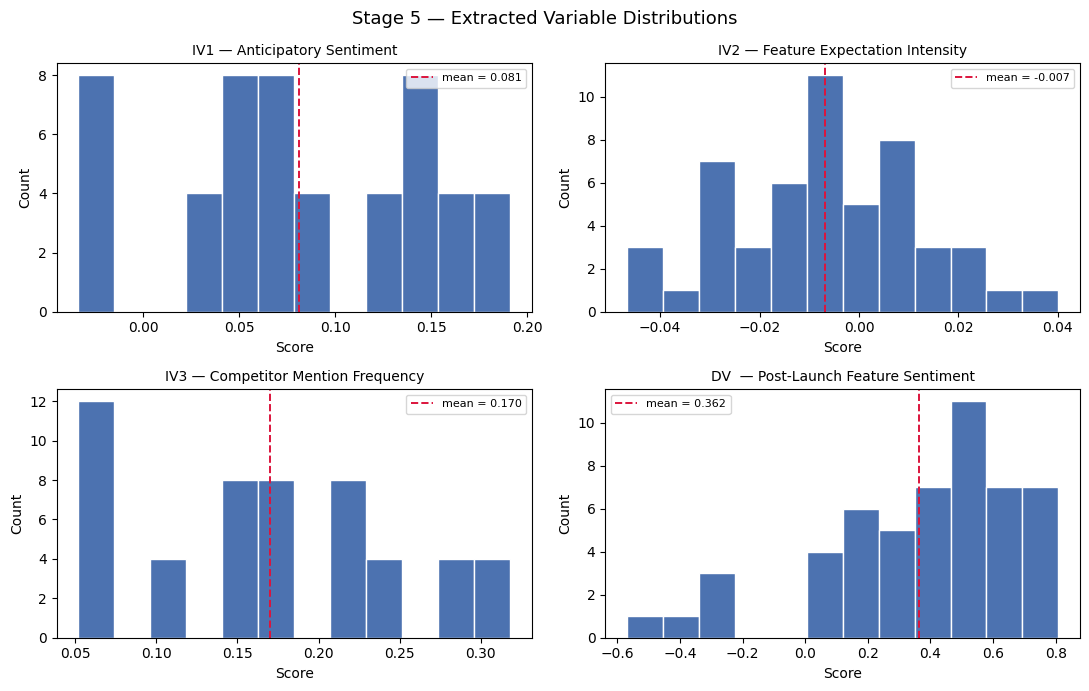

--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 53: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-pr

In [59]:
# ============================================================
# CELL 9 — Descriptive Spot-Check
# Histogram of all four constructed variables.
# Sanity check before handing off to Stage 7 modelling.
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Stage 5 — Extracted Variable Distributions", fontsize=13)

plot_cols = {
    "sentiment_IV1":        "IV1 — Anticipatory Sentiment",
    "pre_expect_score_IV2": "IV2 — Feature Expectation Intensity",
    "competitor_freq_IV3":  "IV3 — Competitor Mention Frequency",
    "post_sentiment_DV":    "DV  — Post-Launch Feature Sentiment",
}

for ax, (col, label) in zip(axes.flat, plot_cols.items()):
    vals = df_model[col].dropna()
    ax.hist(vals, bins=12, edgecolor="white", color="#4C72B0")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.axvline(
        vals.mean(), color="crimson", linestyle="--",
        linewidth=1.4, label=f"mean = {vals.mean():.3f}"
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plot_path = OUTPUT_DIR / "variable_distributions.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
log.info("Spot-check plot saved → %s", plot_path)


# VARIABLE CONSTRUCTION
modelling.ipynb  |  Cells 10–14

Input : thesis_extracted.csv  (40 rows × 13 cols)
Output: thesis_modelling.csv  (40 rows × 20 cols, ready for Stage 7 OLS)

Column inventory going in:
   event | brand | feature | launch_date | product_type
   sentiment_IV1 | pre_expect_score_IV2 | competitor_freq_IV3
   inbrand_freq_IV3b | post_sentiment_DV
   pre_launch_volume | post_review_count | source_mix


In [60]:
# ============================================================
# CELL 10 — Load & Inspect
# ============================================================
import pandas as pd
import numpy as np
import logging
from pathlib import Path
 
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)
 
np.random.seed(42)
 
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
df = pd.read_csv(r"C:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\data\extracted\thesis_extracted.csv")
 
log.info("Loaded: %d rows × %d columns", *df.shape)
print(df.dtypes)
print()
print(df.head(8).to_string())
 
 
# ── Quick sanity checks ─────────────────────────────────────
expected_cols = [
    "event", "brand", "feature", "launch_date", "product_type",
    "sentiment_IV1", "pre_expect_score_IV2", "competitor_freq_IV3",
    "inbrand_freq_IV3b", "post_sentiment_DV",
    "pre_launch_volume", "post_review_count", "source_mix",
]
missing_cols = [c for c in expected_cols if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"
 
assert df.shape[0] >= 32, f"Expected ≥32 rows, got {df.shape[0]}"
assert df["event"].nunique() >= 8, \
    f"Expected ≥8 events, got {df['event'].nunique()}"
 
log.info("Events       : %d", df["event"].nunique())
log.info("Features     : %s", sorted(df["feature"].unique()))
log.info("Hedonic rows : %d", (df["product_type"] == 1).sum())
log.info("Utilitarian  : %d", (df["product_type"] == 0).sum())

2026-06-03 17:27:17,144  INFO  Loaded: 52 rows × 13 columns
2026-06-03 17:27:17,150  INFO  Events       : 13
2026-06-03 17:27:17,151  INFO  Features     : ['battery', 'display', 'performance', 'price']
2026-06-03 17:27:17,152  INFO  Hedonic rows : 32
2026-06-03 17:27:17,153  INFO  Utilitarian  : 20


event                    object
brand                    object
feature                  object
launch_date              object
product_type              int64
sentiment_IV1           float64
pre_expect_score_IV2    float64
competitor_freq_IV3     float64
inbrand_freq_IV3b       float64
post_sentiment_DV       float64
pre_launch_volume         int64
post_review_count         int64
source_mix                int64
dtype: object

           event  brand      feature launch_date  product_type  sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  inbrand_freq_IV3b  post_sentiment_DV  pre_launch_volume  post_review_count  source_mix
0  ipad_pro_2018  Apple      battery  07/11/2018             1         0.2120               -0.0020                0.046              0.956             0.2072                500                200           1
1  ipad_pro_2018  Apple        price  07/11/2018             1         0.2120               -0.0221                0.046              0.956            

In [61]:
# ── Missing values ───────────────────────────────────────────
mv = df.isnull().sum()
mv = mv[mv > 0]
if mv.empty:
    log.info("No missing values — clean.")
else:
    log.warning("Missing values detected:\n%s", mv)
 
# ── DV range check (-1 to 1) ────────────────────────────────
dv_out = df[df["post_sentiment_DV"].abs() > 1]
if not dv_out.empty:
    log.warning("%d DV values outside [-1, 1]:\n%s",
                len(dv_out), dv_out[["event", "feature", "post_sentiment_DV"]])
else:
    log.info("DV range OK — all values within [-1, 1]")
 
# ── Control variable variance check ─────────────────────────
# ⚠️  IF pre_launch_volume / post_review_count are all 500 / 200,
#     these are threshold placeholders, not real counts.
#     Zero-variance controls will be dropped by OLS.
#     Fix: replace with actual counts from BigQuery Gold tables
#     before running Stage 7.
for ctrl in ["pre_launch_volume", "post_review_count"]:
    n_unique = df[ctrl].nunique()
    if n_unique == 1:
        log.warning(
            "⚠️  '%s' has zero variance (all = %s). "
            "Replace with real counts before Stage 7 OLS.",
            ctrl, df[ctrl].iloc[0],
        )
    else:
        log.info("%s: min=%s  max=%s  unique=%d",
                 ctrl, df[ctrl].min(), df[ctrl].max(), n_unique)
 
# ── Hedonic / utilitarian balance ───────────────────────────
events_hedonic = df[df["product_type"] == 1]["event"].nunique()
events_util    = df[df["product_type"] == 0]["event"].nunique()
log.info("Event balance — hedonic: %d  utilitarian: %d",
         events_hedonic, events_util)
 
# ── Feature balance per event ───────────────────────────────
feature_counts = df.groupby("event")["feature"].count()
events_with_gaps = feature_counts[feature_counts < 4]
if not events_with_gaps.empty:
    log.warning("Events with fewer than 4 features:\n%s", events_with_gaps)
else:
    log.info("All events have 4 feature rows — balanced.")

2026-06-03 17:27:20,114  INFO  No missing values — clean.
2026-06-03 17:27:20,116  INFO  DV range OK — all values within [-1, 1]
--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode characters in position 34-35: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\ip

In [62]:
# ============================================================
# CELL 12 — Fix Control Variables (pull real counts from BQ)
# Replaces the placeholder 500 / 200 threshold values with
# actual per-event counts from the Gold tables.
# ============================================================
from google.cloud import bigquery
 
bq = bigquery.Client(project="vuthesis-llm-buzz", location="europe-west4")

pre_q = """
    SELECT product_event AS event, COUNT(*) AS real_pre_launch_volume
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_pre_launch`
    GROUP BY product_event
"""

post_q = """
    SELECT product_event AS event, COUNT(*) AS real_post_review_count
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_post_launch`
    GROUP BY product_event
"""
 
real_pre  = bq.query(pre_q).to_dataframe()
real_post = bq.query(post_q).to_dataframe()
 
# Merge onto df — one value per event, broadcast across its 4 feature rows
df = df.merge(real_pre,  on="event", how="left")
df = df.merge(real_post, on="event", how="left")
 
df["pre_launch_volume"]  = df["real_pre_launch_volume"]
df["post_review_count"]  = df["real_post_review_count"]
 
df.drop(columns=["real_pre_launch_volume", "real_post_review_count"], inplace=True)
 
# Verify variance was recovered
for ctrl in ["pre_launch_volume", "post_review_count"]:
    n_unique = df[ctrl].nunique()
    if n_unique == 1:
        log.warning("⚠️  '%s' still has zero variance — check BQ table.", ctrl)
    else:
        log.info("Control '%s' fixed: min=%d  max=%d  unique_vals=%d",
                 ctrl, df[ctrl].min(), df[ctrl].max(), n_unique)
 
 

c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2026-06-03 17:27:33,863  INFO  Control 'pre_launch_volume' fixed: min=599  max=7448  unique_vals=13
2026-06-03 17:27:33,864  INFO  Control 'post_review_count' fixed: min=190  max=1061  unique_vals=13


In [63]:
# ============================================================
# CELL 13 — Mean-Center IVs
# (Required before constructing interaction terms in Stage 7)
# ============================================================
 
IV_COLS = [
    "sentiment_IV1",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
]
 
for col in IV_COLS:
    col_c = f"{col}_c"
    df[col_c] = df[col] - df[col].mean()
    log.info(
        "Mean-centered %-28s  mean=%.4f → new mean=%.6f",
        col, df[col].mean(), df[col_c].mean(),
    )
 
# Confirm centering worked (mean of centered cols ≈ 0)
for col in IV_COLS:
    assert abs(df[f"{col}_c"].mean()) < 1e-10, \
        f"Centering failed for {col}_c"
 
log.info("All IV centering verified.")
 
 

--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 87: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-pr


── Descriptive statistics ───────────────────────────────
       sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  inbrand_freq_IV3b  post_sentiment_DV  product_type  pre_launch_volume  post_review_count
count        52.0000               52.0000              52.0000            52.0000            52.0000       52.0000               52.0               52.0
mean          0.0721               -0.0079               0.1722             0.9514             0.3622        0.6154          2789.9231           303.6923
std           0.0798                0.0195               0.0856             0.0283             0.3239        0.4913          2033.8001           224.8881
min          -0.0609               -0.0467               0.0460             0.8660            -0.5700        0.0000              599.0              190.0
25%           0.0062               -0.0180               0.1040             0.9440             0.1950        0.0000             1190.0              212.0
50%           0.0

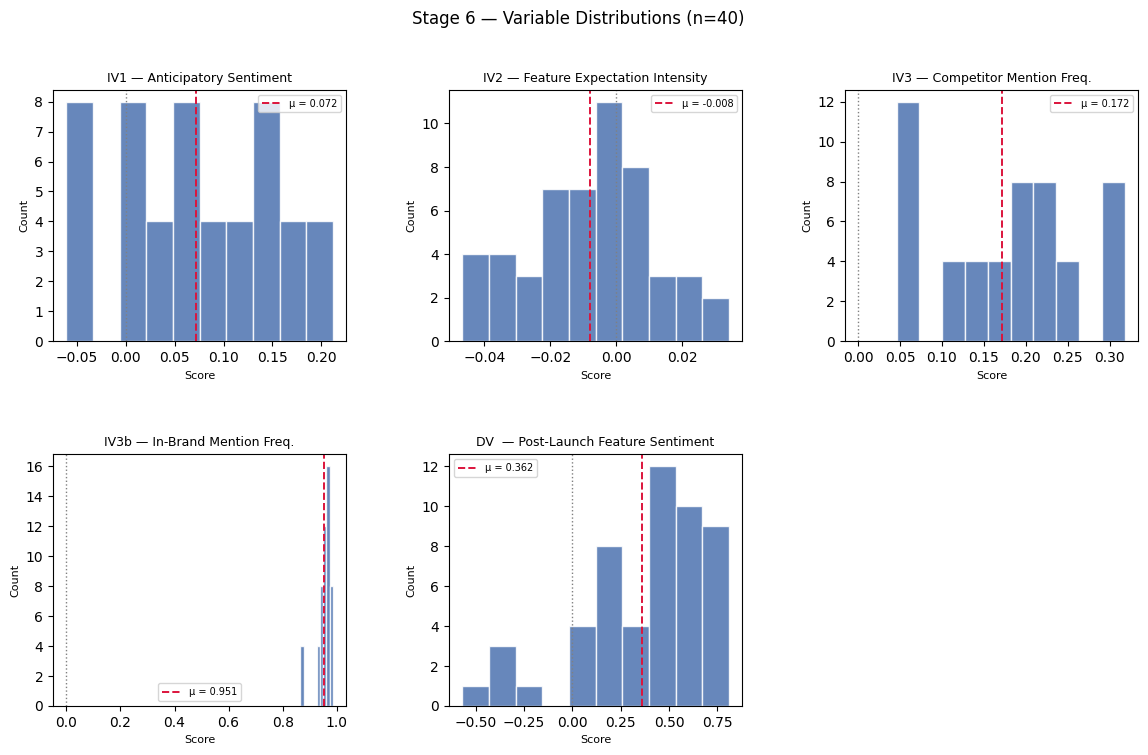

--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 55: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-pr


── DV by product type ───────────────────────────────────
               mean    std    min    max  count
product_type                                   
0             0.512  0.175  0.022  0.766     20
1             0.268  0.361 -0.570  0.809     32

── Per-event variable summary ───────────────────────────
           event  product_type     IV1  IV2_mean   IV3   DV_mean  n_features
   galaxy_s20_fe             1  0.0440 -0.013850 0.150  0.363050           4
galaxy_s21_ultra             1  0.0533 -0.024525 0.104  0.264425           4
galaxy_s22_ultra             1 -0.0609 -0.023825 0.166 -0.135875           4
       galaxy_s6             1  0.0034 -0.004175 0.198  0.108600           4
   galaxy_tab_s2             0  0.0604  0.007875 0.318  0.343050           4
      ipad_air_2             1  0.1430  0.000850 0.058  0.307075           4
     ipad_air_m1             1  0.1286 -0.010050 0.052  0.383025           4
   ipad_pro_2018             1  0.2120  0.010825 0.046  0.312200          

In [64]:
# ============================================================
# CELL 14 — Descriptive Stats & Correlation Matrix
# Sanity check before handing off to Stage 7.
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
MODEL_VARS = [
    "sentiment_IV1",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
    "post_sentiment_DV",
    "product_type",
    "pre_launch_volume",
    "post_review_count",
]
 
print("\n── Descriptive statistics ───────────────────────────────")
print(df[MODEL_VARS].describe().round(4).to_string())
 
print("\n── Correlation matrix (IVs + DV) ────────────────────────")
corr_vars = [
    "sentiment_IV1", "pre_expect_score_IV2",
    "competitor_freq_IV3", "inbrand_freq_IV3b", "post_sentiment_DV",
]
print(df[corr_vars].corr().round(3).to_string())
 
# ── Distribution plots ───────────────────────────────────────
plot_map = {
    "sentiment_IV1":         "IV1 — Anticipatory Sentiment",
    "pre_expect_score_IV2":  "IV2 — Feature Expectation Intensity",
    "competitor_freq_IV3":   "IV3 — Competitor Mention Freq.",
    "inbrand_freq_IV3b":     "IV3b — In-Brand Mention Freq.",
    "post_sentiment_DV":     "DV  — Post-Launch Feature Sentiment",
}
 
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
for idx, (col, label) in enumerate(plot_map.items()):
    ax   = fig.add_subplot(gs[idx // 3, idx % 3])
    vals = df[col].dropna()
    ax.hist(vals, bins=10, edgecolor="white", color="#4C72B0", alpha=0.85)
    ax.axvline(vals.mean(), color="crimson", linestyle="--",
               linewidth=1.4, label=f"μ = {vals.mean():.3f}")
    ax.axvline(0, color="grey", linestyle=":", linewidth=1.0)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Score", fontsize=8)
    ax.set_ylabel("Count",  fontsize=8)
    ax.legend(fontsize=7)
 
fig.suptitle("Stage 6 — Variable Distributions (n=40)", fontsize=12)
plot_path = OUTPUT_DIR / "stage6_distributions.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
log.info("Distribution plot saved → %s", plot_path)
 
# ── Hedonic vs utilitarian DV comparison ─────────────────────
print("\n── DV by product type ───────────────────────────────────")
print(df.groupby("product_type")["post_sentiment_DV"]
      .agg(["mean", "std", "min", "max", "count"]).round(3))
 
# ── Per-event IV summary ─────────────────────────────────────
print("\n── Per-event variable summary ───────────────────────────")
event_summary = df.groupby(["event", "product_type"]).agg(
    IV1=("sentiment_IV1",        "first"),
    IV2_mean=("pre_expect_score_IV2", "mean"),
    IV3=("competitor_freq_IV3",  "first"),
    DV_mean=("post_sentiment_DV", "mean"),
    n_features=("feature", "count"),
).reset_index()
print(event_summary.to_string(index=False))
 
 

In [53]:
# ============================================================
# CELL 15 — Save Modelling-Ready CSV
# ============================================================
 
# Final column order for thesis_modelling.csv
FINAL_COLS = [
    # Identifiers
    "event", "brand", "feature", "launch_date", "product_type",
    # Raw IVs
    "sentiment_IV1",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
    # Mean-centered IVs (used in interaction terms)
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "inbrand_freq_IV3b_c",
    # DV
    "post_sentiment_DV",
    # Controls
    "pre_launch_volume",
    "post_review_count",
    # Metadata
    "source_mix",
]
 
df_out = df[FINAL_COLS].copy()
 
out_path = OUTPUT_DIR / "thesis_modelling.csv"
df_out.to_csv(out_path, index=False)
log.info("Stage 6 complete — modelling CSV saved → %s", out_path)
 
print(f"\n── Final dataset ────────────────────────────────────────")
print(f"Rows        : {len(df_out)}")
print(f"Columns     : {len(df_out.columns)}")
print(f"Events      : {df_out['event'].nunique()}")
print(f"Hedonic     : {(df_out['product_type']==1).sum()} rows "
      f"({df_out[df_out['product_type']==1]['event'].nunique()} events)")
print(f"Utilitarian : {(df_out['product_type']==0).sum()} rows "
      f"({df_out[df_out['product_type']==0]['event'].nunique()} events)")
print(f"Missing DV  : {df_out['post_sentiment_DV'].isna().sum()} rows")
print(f"\nColumn list :")
for c in df_out.columns:
    print(f"  {c}")

--- Logging error ---
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 70: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\Desktop\VU\Thesis\Code\LLM-pr


── Final dataset ────────────────────────────────────────
Rows        : 40
Columns     : 17
Events      : 10
Hedonic     : 24 rows (6 events)
Utilitarian : 16 rows (4 events)
Missing DV  : 0 rows

Column list :
  event
  brand
  feature
  launch_date
  product_type
  sentiment_IV1
  pre_expect_score_IV2
  competitor_freq_IV3
  inbrand_freq_IV3b
  sentiment_IV1_c
  pre_expect_score_IV2_c
  competitor_freq_IV3_c
  inbrand_freq_IV3b_c
  post_sentiment_DV
  pre_launch_volume
  post_review_count
  source_mix


---
# ADDITIONAL SAMPLE

In [40]:
# ============================================================
# CELL — Marginal Product Audit
# Counts pre and post launch corpus size for all events in GCS,
# including those currently below the 500/200 thresholds.
# ============================================================
from google.cloud import bigquery

bq = bigquery.Client(project="vuthesis-llm-buzz", location="europe-west4")

q = """
    SELECT
        product_event                           AS event,
        COUNT(*)                                AS pre_launch_n,
        MIN(days_to_launch)                     AS days_to_launch_min,
        MAX(days_to_launch)                     AS days_to_launch_max
    FROM `vuthesis-llm-buzz.thesis_dataset.silver_reddit`
    GROUP BY product_event
    ORDER BY pre_launch_n DESC
"""

df_pre_all = bq.query(q).to_dataframe()

q2 = """
    SELECT
        product_event                           AS event,
        COUNT(*)                                AS post_review_n
    FROM `vuthesis-llm-buzz.thesis_dataset.silver_amazon`
    GROUP BY product_event
    ORDER BY post_review_n DESC
"""

df_post_all = bq.query(q2).to_dataframe()

df_audit = df_pre_all.merge(df_post_all, on="event", how="outer").fillna(0)
df_audit["pre_launch_n"]  = df_audit["pre_launch_n"].astype(int)
df_audit["post_review_n"] = df_audit["post_review_n"].astype(int)

# Flag status relative to thresholds
df_audit["pre_ok"]  = df_audit["pre_launch_n"]  >= 500
df_audit["post_ok"] = df_audit["post_review_n"] >= 200

def classify(row):
    if row["pre_ok"] and row["post_ok"]:
        return "✓ qualified"
    elif row["pre_launch_n"] >= 300 and row["post_review_n"] >= 150:
        return "~ marginal"
    else:
        return "✗ excluded"

df_audit["status"] = df_audit.apply(classify, axis=1)

print("── Full event audit ────────────────────────────────────")
print(df_audit[["event", "pre_launch_n", "post_review_n", "status"]]
      .sort_values("status").to_string(index=False))

print(f"\n── Summary ─────────────────────────────────────────────")
print(df_audit["status"].value_counts().to_string())

c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


── Full event audit ────────────────────────────────────
           event  pre_launch_n  post_review_n      status
galaxy_s21_ultra           769            190  ~ marginal
      ipad_air_2          1758            198  ~ marginal
   galaxy_s20_fe          2754            224 ✓ qualified
galaxy_s22_ultra          3713            250 ✓ qualified
       galaxy_s6          5269            204 ✓ qualified
   galaxy_tab_s2           599           1061 ✓ qualified
     ipad_air_m1          1361            213 ✓ qualified
   ipad_pro_2018          2906            317 ✓ qualified
           lg_g3          2802            214 ✓ qualified
  moto_g_3rd_gen           674            304 ✓ qualified
     moto_g_fast          1190            212 ✓ qualified
        pixel_3a          5026            248 ✓ qualified
        pixel_4a          7448            313 ✓ qualified
  moto_g_4th_gen           190            381  ✗ excluded

── Summary ─────────────────────────────────────────────
status
✓ qualif

In [41]:
import os
from pathlib import Path

EXTRACT_DIR = Path(
    r"C:\Users\User\Desktop\VU\Thesis\Code"
    r"\LLM-prelaunch-buzz-postlaunch-predictor\data\extracted"
)

candidates = ["moto_g_3rd_gen", "ipad_air_2", "galaxy_s21_ultra"]

for event in candidates:
    files = list(EXTRACT_DIR.glob(f"*{event}*"))
    if files:
        print(f"✓ {event}: {[f.name for f in files]}")
    else:
        print(f"✗ {event}: no extraction files found")

✗ moto_g_3rd_gen: no extraction files found
✗ ipad_air_2: no extraction files found
✗ galaxy_s21_ultra: no extraction files found


In [42]:
q = """
    SELECT
        product_event,
        COUNT(*) AS n_posts
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_pre_launch`
    WHERE product_event IN ('moto_g_3rd_gen', 'ipad_air_2', 'galaxy_s21_ultra')
    GROUP BY product_event
"""
print(bq.query(q).to_dataframe().to_string(index=False))

q2 = """
    SELECT
        product_event,
        COUNT(*) AS n_reviews
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_post_launch`
    WHERE product_event IN ('moto_g_3rd_gen', 'ipad_air_2', 'galaxy_s21_ultra')
    GROUP BY product_event
"""
print(bq.query(q2).to_dataframe().to_string(index=False))

c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   product_event  n_posts
galaxy_s21_ultra      769
      ipad_air_2     1758
  moto_g_3rd_gen      674
   product_event  n_reviews
galaxy_s21_ultra        190
      ipad_air_2        198
  moto_g_3rd_gen        304


c:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [45]:
# ============================================================
# TARGETED RE-RUN — specific events only
# Adds to existing checkpoints without reprocessing done docs
# ============================================================

NEW_EVENTS = {"moto_g_3rd_gen", "ipad_air_2", "galaxy_s21_ultra"}

# ── Pre-launch ────────────────────────────────────────────
df_new_pre = df_pre[df_pre["product_event"].isin(NEW_EVENTS)].reset_index(drop=True)
df_new_pre = (
    df_new_pre
    .groupby("product_event", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 500), random_state=42))
    .reset_index(drop=True)
)
log.info("New events pre-launch: %d rows", len(df_new_pre))

for _, row in df_new_pre.iterrows():
    doc_id = str(row["post_id"])
    if doc_id in pre_results:
        continue
    text         = str(row["text"])
    product_name = row["product_event"]
    overall      = extract_overall(text, product_name)
    feature_results = {}
    for feat in FEATURES:
        feature_results[feat] = extract_feature_synchain(text, product_name, feat)
    pre_results[doc_id] = {
        "product_event": product_name,
        "doc_id":        doc_id,
        "overall":       overall,
        "features":      feature_results,
    }

with open(CKPT_PRE, "w") as f:
    json.dump(pre_results, f)
log.info("Pre-launch checkpoint updated — total docs: %d", len(pre_results))

# ── Post-launch ───────────────────────────────────────────
df_new_post = df_post[df_post["product_event"].isin(NEW_EVENTS)].reset_index(drop=True)
df_new_post = (
    df_new_post
    .groupby("product_event", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 200), random_state=42))
    .reset_index(drop=True)
)
log.info("New events post-launch: %d rows", len(df_new_post))

for _, row in df_new_post.iterrows():
    doc_id = str(row["review_id"])
    if doc_id in post_results:
        continue
    text         = str(row["text"])
    product_name = row["product_event"]
    overall      = extract_overall(text, product_name)
    feature_results = {}
    for feat in FEATURES:
        feature_results[feat] = extract_feature_synchain(text, product_name, feat)
    post_results[doc_id] = {
        "product_event": product_name,
        "doc_id":        doc_id,
        "source":        "amazon",
        "overall":       overall,
        "features":      feature_results,
    }

with open(CKPT_POST, "w") as f:
    json.dump(post_results, f)
log.info("Post-launch checkpoint updated — total docs: %d", len(post_results))
log.info("Done. Now re-run Cells 7, 8, 9 to regenerate thesis_extracted.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_53600\1128799780.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 500), random_state=42))
2026-06-01 21:29:42,192  INFO  New events pre-launch: 1500 rows
2026-06-01 21:29:55,397  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-06-01 21:29:59,030  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-06-01 21:30:02,173  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-06-01 21:30:04,512  INFO  HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-06-01 21:30:06,340  INFO  HTTP Request: POST http://127.0.0.1:1143

In [54]:
NEW_EVENTS = {"moto_g_3rd_gen", "ipad_air_2", "galaxy_s21_ultra"}
ALL_THESIS_EVENTS = THESIS_EVENTS | NEW_EVENTS

pre_remaining  = df_pre[df_pre["product_event"].isin(ALL_THESIS_EVENTS)]
pre_remaining  = pre_remaining[~pre_remaining["post_id"].astype(str).isin(pre_results.keys())]
post_remaining = df_post[df_post["product_event"].isin(ALL_THESIS_EVENTS)]
post_remaining = post_remaining[~post_remaining["review_id"].astype(str).isin(post_results.keys())]

print("Pre-launch remaining:", len(pre_remaining))
print("Post-launch remaining:", len(post_remaining))
print()
print(pre_remaining["product_event"].value_counts())

Pre-launch remaining: 29769
Post-launch remaining: 1360

product_event
pixel_4a            6948
galaxy_s6           4769
pixel_3a            4526
galaxy_s22_ultra    3213
ipad_pro_2018       2406
lg_g3               2302
galaxy_s20_fe       2254
ipad_air_2          1258
ipad_air_m1          861
moto_g_fast          690
galaxy_s21_ultra     269
moto_g_3rd_gen       174
galaxy_tab_s2         99
Name: count, dtype: int64


In [56]:
# ============================================================
# PRE-LAUNCH TOP-UP — tiered caps by event
# Post-launch — no additional processing
# ============================================================

NEW_EVENTS = {"moto_g_3rd_gen", "ipad_air_2", "galaxy_s21_ultra"}
ALL_THESIS_EVENTS = THESIS_EVENTS | NEW_EVENTS

# Tiered pre-launch caps (total docs per event including already processed)
PRE_TOTAL_CAP = {
    "pixel_4a":         2000,
    "pixel_3a":         2000,
    "galaxy_s6":        2000,
    "galaxy_s22_ultra": 1000,
    "ipad_pro_2018":    1000,
}
PRE_DEFAULT_CAP = 500  # all other events — already at limit, skip

# ── Count already processed per event ────────────────────
from collections import Counter
already_done_pre = Counter(
    v["product_event"] for v in pre_results.values()
)
log.info("Already processed per event:")
for evt, n in sorted(already_done_pre.items()):
    cap = PRE_TOTAL_CAP.get(evt, PRE_DEFAULT_CAP)
    log.info("  %-25s done=%d  cap=%d  remaining=%d", evt, n, cap, max(0, cap-n))

# ── Build top-up dataframe ────────────────────────────────
df_all_pre = df_pre[df_pre["product_event"].isin(ALL_THESIS_EVENTS)].reset_index(drop=True)
df_all_pre = df_all_pre[
    ~df_all_pre["post_id"].astype(str).isin(pre_results.keys())
].reset_index(drop=True)

def apply_topup_cap(g):
    event     = g["product_event"].iloc[0]
    total_cap = PRE_TOTAL_CAP.get(event, PRE_DEFAULT_CAP)
    done      = already_done_pre.get(event, 0)
    remaining = max(0, total_cap - done)
    if remaining == 0:
        return g.iloc[0:0]
    return g.sample(min(len(g), remaining), random_state=42)

df_topup_pre = (
    df_all_pre
    .groupby("product_event", group_keys=False)
    .apply(apply_topup_cap)
    .reset_index(drop=True)
)
log.info("Pre-launch top-up after tiered caps: %d rows", len(df_topup_pre))
log.info("\n%s", df_topup_pre["product_event"].value_counts().to_string())

# ── Extraction loop ───────────────────────────────────────
total = len(df_topup_pre)
for i, (_, row) in enumerate(df_topup_pre.iterrows()):
    doc_id       = str(row["post_id"])
    text         = str(row["text"])
    product_name = row["product_event"]

    overall = extract_overall(text, product_name)
    feature_results = {}
    for feat in FEATURES:
        feature_results[feat] = extract_feature_synchain(text, product_name, feat)

    pre_results[doc_id] = {
        "product_event": product_name,
        "doc_id":        doc_id,
        "overall":       overall,
        "features":      feature_results,
    }

    done = i + 1
    if done % 50 == 0:
        with open(CKPT_PRE, "w") as f:
            json.dump(pre_results, f)
        log.info("Pre top-up — %d/%d  (%.1f%%)", done, total, done/total*100)

with open(CKPT_PRE, "w") as f:
    json.dump(pre_results, f)
log.info("Pre-launch top-up complete. Total checkpoint: %d docs", len(pre_results))
log.info("Done. Re-run Cells 7, 8, 9 to regenerate thesis_extracted.csv")

2026-06-02 13:33:30,506  INFO  Already processed per event:
2026-06-02 13:33:30,509  INFO    galaxy_s20_fe             done=500  cap=500  remaining=0
2026-06-02 13:33:30,510  INFO    galaxy_s21_ultra          done=500  cap=500  remaining=0
2026-06-02 13:33:30,511  INFO    galaxy_s22_ultra          done=500  cap=1000  remaining=500
2026-06-02 13:33:30,512  INFO    galaxy_s6                 done=500  cap=2000  remaining=1500
2026-06-02 13:33:30,513  INFO    galaxy_tab_s2             done=500  cap=500  remaining=0
2026-06-02 13:33:30,514  INFO    ipad_air_2                done=500  cap=500  remaining=0
2026-06-02 13:33:30,514  INFO    ipad_air_m1               done=500  cap=500  remaining=0
2026-06-02 13:33:30,515  INFO    ipad_pro_2018             done=500  cap=1000  remaining=500
2026-06-02 13:33:30,517  INFO    lg_g3                     done=500  cap=500  remaining=0
2026-06-02 13:33:30,518  INFO    moto_g_3rd_gen            done=500  cap=500  remaining=0
2026-06-02 13:33:30,519  INFO 

In [66]:
from collections import Counter
import pandas as pd

# Count processed docs per event in checkpoints
pre_counts  = Counter(v["product_event"] for v in pre_results.values())
post_counts = Counter(v["product_event"] for v in post_results.values())

# Count total available per event in Gold tables
ALL_THESIS_EVENTS = THESIS_EVENTS | {"moto_g_3rd_gen", "ipad_air_2", "galaxy_s21_ultra"}
pre_total  = df_pre[df_pre["product_event"].isin(ALL_THESIS_EVENTS)]["product_event"].value_counts().to_dict()
post_total = df_post[df_post["product_event"].isin(ALL_THESIS_EVENTS)]["product_event"].value_counts().to_dict()

# Build summary table
rows = []
for event in sorted(ALL_THESIS_EVENTS):
    pre_done  = pre_counts.get(event, 0)
    post_done = post_counts.get(event, 0)
    pre_avail = pre_total.get(event, 0)
    post_avail = post_total.get(event, 0)
    rows.append({
        "event":         event,
        "pre_sampled":   pre_done,
        "pre_total":     pre_avail,
        "pre_%":         round(pre_done / pre_avail * 100, 1) if pre_avail > 0 else 0,
        "post_sampled":  post_done,
        "post_total":    post_avail,
        "post_%":        round(post_done / post_avail * 100, 1) if post_avail > 0 else 0,
    })

df_audit = pd.DataFrame(rows)
print(df_audit.to_string(index=False))

           event  pre_sampled  pre_total  pre_%  post_sampled  post_total  post_%
   galaxy_s20_fe          500       2754   18.2           200         224    89.3
galaxy_s21_ultra          500        769   65.0           190         190   100.0
galaxy_s22_ultra         1000       3713   26.9           200         250    80.0
       galaxy_s6         2000       5269   38.0           200         204    98.0
   galaxy_tab_s2          500        599   83.5           200        1061    18.9
      ipad_air_2          500       1758   28.4           198         198   100.0
     ipad_air_m1          500       1361   36.7           200         213    93.9
   ipad_pro_2018         1000       2906   34.4           200         317    63.1
           lg_g3          500       2802   17.8           200         214    93.5
  moto_g_3rd_gen          500        674   74.2           200         304    65.8
     moto_g_fast          500       1190   42.0           200         212    94.3
        pixel_3a